#  Sumário Executivo

## Contexto
A **BF LUBS** é uma empresa fictícia especializada na **produção e distribuição de lubrificantes industriais**, com atuação em múltiplas regiões do Brasil e atendimento a setores como Energia e Químicos, Ciência e Saúde e Manufatura. Entre 2018 e 2024, a empresa registrou uma **queda expressiva no volume de vendas**, levantando preocupações estratégicas sobre sua competitividade e sustentabilidade no mercado.

## O que foi feito
Foi conduzida uma **Análise Descritiva e Exploratória de Dados (EDA)** sobre o histórico de vendas da empresa, cobrindo as seguintes etapas:

1. **Carregamento e inspeção dos dados** — verificação da estrutura, tipos de variáveis e qualidade dos dados.
2. **Análise de tendências temporais** — evolução do volume, receita, preço médio e número de clientes ativos ao longo do tempo.
3. **Segmentação por produto, mercado, região e estado** — identificação de onde e em quais categorias a queda é mais intensa.
4. **Segmentação de clientes por faixa de volume** — classificação dos clientes em perfis de consumo (Baixo, Médio, Alto e Muito Alto) para entender quais perfis concentram a perda.
5. **Tratamento de outliers** — aplicação do método IQR e uso de conhecimento de domínio para definir limites realistas.
6. **Comparação 2018 vs. 2024** — análise da variação de volume médio mensal por região, mercado e faixa de cliente.
7. **Análise de Pareto** — identificação dos segmentos que mais contribuíram para a queda acumulada de volume.

## Principais Achados

| Achado | Detalhe |
|---|---|
|  Queda de volume concentrada no Lubs1 | O produto Lubs1 é o principal responsável pelo declínio, sendo o de maior volume histórico |
|  Receita resistente apesar da queda de volume | O aumento do preço médio sustentou a receita, mascarando a erosão de base de clientes |
|  Perda crítica na faixa "Muito Alto" | Clientes com volume acima de 900 L/mês reduziram tanto volume quanto quantidade |
|  Queda distribuída geograficamente | Nenhuma região ou estado isolado explica a queda, embora as regiões Sul e Sudeste apresentem maiores bases de venda; o problema é sistêmico |
|  Mercados-chave: Energia/Químicos, Ciência/Saúde e Manufatura | Esses segmentos representam o maior volume e, portanto, o maior risco de perda |
|  Pareto revela focos prioritários | Poucos segmentos concentram a maior parte da queda acumulada |

## Conclusão
A BF LUBS enfrenta um problema estrutural de perda de clientes de alto valor. A queda de volume não é pontual ou sazonal — é uma tendência de longo prazo que impacta de forma transversal regiões, estados e mercados. A prioridade estratégica deve ser a **retenção e recuperação dos clientes de faixa "Muito Alto"**, com foco especial nos segmentos identificados na análise de Pareto.

---

# Contexto: A Situação da BF LUBS

A **BF LUBS**, uma empresa especializada na produção e distribuição de lubrificantes industriais, tem enfrentado uma **queda constante no volume de vendas nos últimos anos**. Apesar de ser reconhecida pela qualidade de seus produtos, a empresa observou uma redução significativa no número de clientes ativos e na quantidade de pedidos realizados.

Essa queda tem impactado diretamente a **participação de mercado** da BF LUBS, colocando em risco sua posição de destaque no setor. Curiosamente, mesmo com o declínio no volume de vendas, a **receita total** apresentou leve aumento, indicando possíveis alterações no mix de produtos ou mudanças no comportamento dos clientes.

# Objetivo da análise
Através da análise exploratória, entender as questões associadas a queda de volume da organização, descrevendo cada etapa e resultado para o fácil entendimento do leitor e, ao fim, sugerir os próximos passos a serem tomados pela empresa BF LUBS.

# Perguntas do negócio

1. *Quais produtos são os maiores responsáveis pela queda?*
2. *A queda de volume está impactando a receita da empresa?*
3. *Quais perfis de clientes (por volume de compra) estão sendo mais perdidos?*
4. *A queda está concentrada em algum mercado específico ou é generalizada?*
5. *A empresa está perdendo clientes, ou os clientes existentes estão comprando menos — ou ambos?*
6. *Quais ações a empresa deve tomar para recuperar seu volume de vendas?*




---
## 1. Configuração do Ambiente e carregamento dos dados

Antes de iniciar qualquer análise, é necessário preparar o ambiente de trabalho. Nesta etapa, importamos as bibliotecas utilizadas, carregamos os dados e configuramos eles. Essa etapa é fundamental para entender a estrutura do dataset: Quais colunas estão disponíveis, quais são os tipos de dados e se há valores ausentes ou inconsistências que precisam ser tratadas antes da análise.

Bibliotecas utilizadas:
- **pandas** — manipulação e análise de dados tabulares
- **matplotlib / seaborn** — criação de visualizações gráficas
- **warnings** — supressão de alertas desnecessários durante a execução

In [1]:
#Bibliotecas
import pandas as pd
import seaborn as sns
import warnings 
import matplotlib.pyplot as plt

# Libraries

import pandas as pd
import seaborn as sns
import warnings
import matplotlib.pyplot as plt

# Columns and rows

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)
pd.options.display.float_format = '{:,.2f}'.format


In [2]:
#Importando os dados
#Verificando colunas
df= pd.read_csv('BF LUBS Sales.csv') 
df.sample(10)

,Ano e Mês,ID Cliente,Nome Cliente,Produto,UoM,Volume,Receita,Preço,Mercado,Regiao,Latitude_Regional,Longitude_Regional,Estado,Filial,Latitude_Filial,Longitude_Filial,Latitude_Cliente,Longitude_Cliente
323647,2023-10,BF-CL1000211,Cliente_212,LUB-BF-SPEC-01,LT,584,1500,2.57,Manufatura,Nordeste,-8.05,-34.88,Piauí,Parnaíba,-2.91,-41.77,-2.61,-41.58
172068,2020-07,BF-CL1001186,Cliente_1187,LUB-BF-SPEC-01,LT,1752,895,0.51,Ciências e Saúde,Sudeste,-23.55,-46.63,Espírito Santo,Vitória,-20.32,-40.34,-20.13,-40.22
34398,2022-03,BF-CL1000241,Cliente_242,LUB-BF-SPEC-01,LT,2044,4510,2.21,Governo,Sul,-25.43,-49.27,Paraná,Londrina,-23.31,-51.16,-22.99,-51.24
465781,2020-05,BF-CL1007122,Cliente_7123,LUB-BF-SPEC-01,LT,2628,3072,1.17,Ciências e Saúde,Sudeste,-23.55,-46.63,Rio de Janeiro,Rio de Janeiro,-22.91,-43.21,-22.80,-42.93
341630,2024-04,BF-CL1000132,Cliente_133,LUB-BF-SPEC-01,LT,292,141,0.48,Ciências e Saúde,Sul,-25.43,-49.27,Paraná,Curitiba,-25.43,-49.27,-25.18,-49.66
14565,2019-11,BF-CL1000008,Cliente_9,LUB-BF-SPEC-01,LT,584,584,1.00,Energia e Químicos,Sul,-25.43,-49.27,Santa Catarina,Chapecó,-27.09,-52.62,-27.51,-52.69
525121,2020-07,BF-CL1004130,Cliente_4131,LUB-BF-SPEC-01,LT,512,427,0.83,Ciências e Saúde,Sudeste,-23.55,-46.63,Espírito Santo,Vila Velha,-20.33,-40.29,-20.75,-40.43
255811,2019-06,BF-CL1000024,Cliente_25,LUB-BF-SPEC-01,LT,9344,6424,0.69,Energia e Químicos,Sudeste,-23.55,-46.63,Rio de Janeiro,Rio de Janeiro,-22.91,-43.21,-22.78,-43.43
219463,2020-03,BF-CL1005261,Cliente_5262,LUB-BF-SPEC-01,LT,2920,2732,0.94,Manufatura,Centro Oeste,-15.78,-47.93,Goiás,Goiânia,-16.68,-49.25,-16.81,-48.81
300545,2023-05,BF-CL1000370,Cliente_371,LUB-BF-SPEC-01,LT,584,376,0.65,Energia e Químicos,Sul,-25.43,-49.27,Rio Grande do Sul,Caxias do Sul,-29.17,-51.18,-29.12,-51.48


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 601836 entries, 0 to 601835
Data columns (total 18 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   Ano e Mês           601836 non-null  str    
 1   ID Cliente          601836 non-null  str    
 2   Nome Cliente        601836 non-null  str    
 3   Produto             601836 non-null  str    
 4   UoM                 601836 non-null  str    
 5   Volume              601836 non-null  int64  
 6   Receita             601836 non-null  int64  
 7   Preço               601836 non-null  float64
 8   Mercado             596037 non-null  str    
 9   Regiao              601836 non-null  str    
 10  Latitude_Regional   601836 non-null  float64
 11  Longitude_Regional  601836 non-null  float64
 12  Estado              601836 non-null  str    
 13  Filial              601836 non-null  str    
 14  Latitude_Filial     601836 non-null  float64
 15  Longitude_Filial    601836 non-null  float64


In [4]:
df['Ano e Mês'] = pd.to_datetime(df['Ano e Mês'], format= '%Y-%m') #Transformando o ano e mês para datetime
df.sample(5)

,Ano e Mês,ID Cliente,Nome Cliente,Produto,UoM,Volume,Receita,Preço,Mercado,Regiao,Latitude_Regional,Longitude_Regional,Estado,Filial,Latitude_Filial,Longitude_Filial,Latitude_Cliente,Longitude_Cliente
452390,2020-08-01,BF-CL1003087,Cliente_3088,LUB-BF-SPEC-01,LT,4088,12015,2.94,Governo,Nordeste,-8.05,-34.88,Sergipe,Aracaju,-10.92,-37.08,-10.90,-37.35
174659,2023-06-01,BF-CL1003201,Cliente_3202,LUB-BF-SPEC-01,LT,584,1325,2.27,Manufatura,Centro Oeste,-15.78,-47.93,Goiás,Aparecida de Goiânia,-16.82,-49.25,-16.84,-49.24
198667,2019-05-01,BF-CL1000794,Cliente_795,LUB-BF-SPEC-01,LT,292,147,0.51,Governo,Nordeste,-8.05,-34.88,Sergipe,Aracaju,-10.92,-37.08,-11.00,-37.13
561475,2023-06-01,BF-CL1004845,Cliente_4846,LUB-BF-SPEC-01,LT,584,1518,2.60,Manufatura,Sudeste,-23.55,-46.63,Espírito Santo,Vitória,-20.32,-40.34,-20.01,-40.66
407733,2024-06-01,BF-CL1004076,Cliente_4077,LUB-BF-SPEC-02,LT,584,741,1.27,Ciências e Saúde,Sul,-25.43,-49.27,Paraná,Ponta Grossa,-25.09,-50.16,-25.02,-50.52



## 2. Análise de Tendências Temporais

Com os dados carregados, analisamos as **principais métricas de negócio ao longo do tempo**: volume vendido, receita gerada, número de clientes ativos e preço médio. Esses gráficos fornecem a visão macro da evolução da empresa e são o ponto de partida para identificar onde e quando a situação começou a se deteriorar.

<Axes: title={'center': 'Volume por ano e mês'}, xlabel='Ano e Mês'>

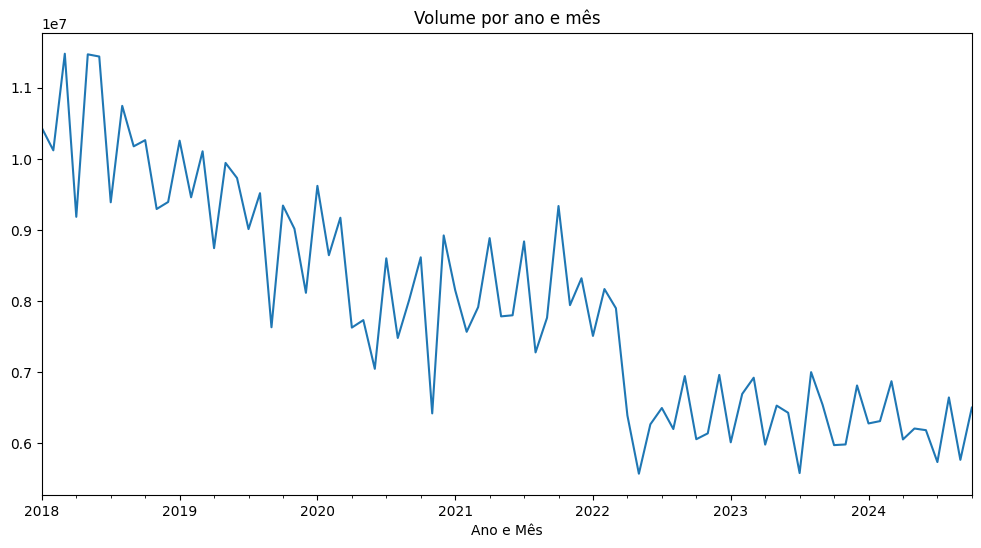

In [47]:
#Volume
Volume_por_mes = df.groupby('Ano e Mês')['Volume'].sum() #
Volume_por_mes.plot(kind= 'line',title='Volume por ano e mês',figsize=(12,6))
#Queda de 2018 até 2020, após queda grande em 2022, dados se estabilizam.

**Interpretação — Volume por Ano e Mês**

O gráfico revela uma **tendência de queda contínua no volume total vendido** entre 2018 e 2024. A queda é mais proeminente entre 2018 e 2020, com um segundo colapso expressivo por volta de 2022. Após esse ponto, o volume se estabiliza em patamar significativamente inferior ao inicial. 

<Axes: title={'center': 'Receita por ano e mês'}, xlabel='Ano e Mês'>

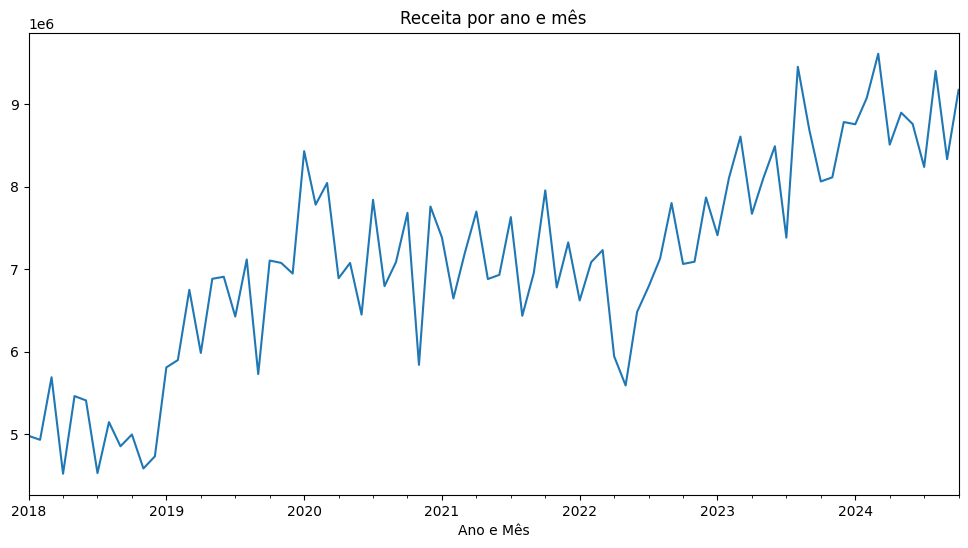

In [48]:
#Receita
Receita_por_mes = df.groupby('Ano e Mês')['Receita'].sum() #
Receita_por_mes.plot(kind= 'line',title='Receita por ano e mês',figsize=(12,6))

**Interpretação — Receita por Ano e Mês**

Diferentemente do volume, a **Receita apresenta um crescimento sustentado**, esse crescimento indica que de alguma maneira a empresa tem compensado a perda de volume, seja através de uma operação mais eficiente, aumento de preços ou mudança no mix de produtos.

Index(['Ano e Mês', 'ID Cliente', 'Nome Cliente', 'Produto', 'UoM', 'Volume',
       'Receita', 'Preço', 'Mercado', 'Regiao', 'Latitude_Regional',
       'Longitude_Regional', 'Estado', 'Filial', 'Latitude_Filial',
       'Longitude_Filial', 'Latitude_Cliente', 'Longitude_Cliente',
       'Faixa de Volume'],
      dtype='str')

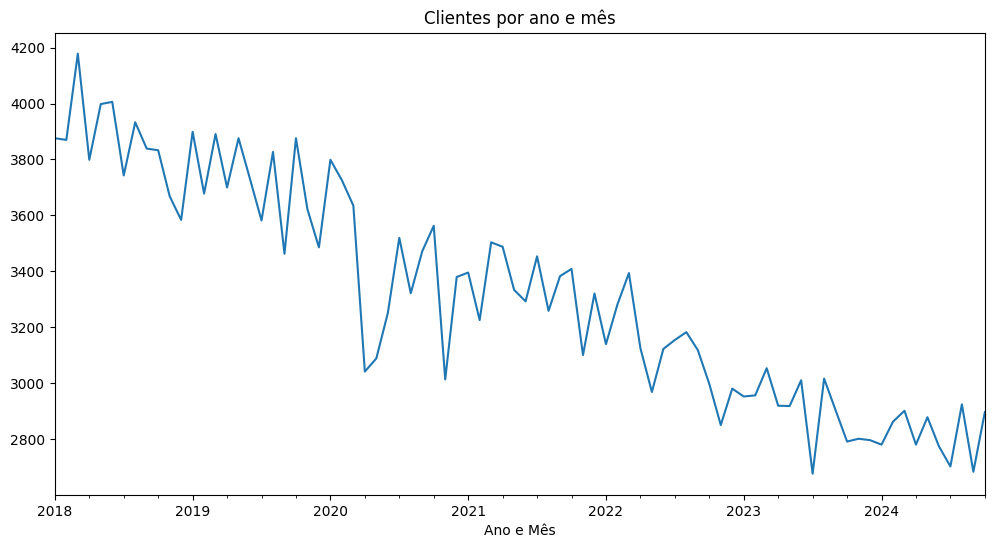

In [49]:
#Clientes
Clientes_por_mes = df.groupby('Ano e Mês')['ID Cliente'].nunique() #
Clientes_por_mes.plot(kind= 'line',title='Clientes por ano e mês',figsize=(12,6))
df.columns

**Interpretação — Clientes por Ano e Mês**

O número de clientes ativos mensais também apresenta **queda consistente ao longo do período**. A perda de clientes acompanha, e provavelmente explica em grande parte, a queda no volume. Vale destacar que não se trata de uma oscilação sazonal: a tendência é unidirecional e persistente, configurando um problema estrutural de retenção de clientes.

<Axes: title={'center': 'Preço por ano e mês'}, xlabel='Ano e Mês'>

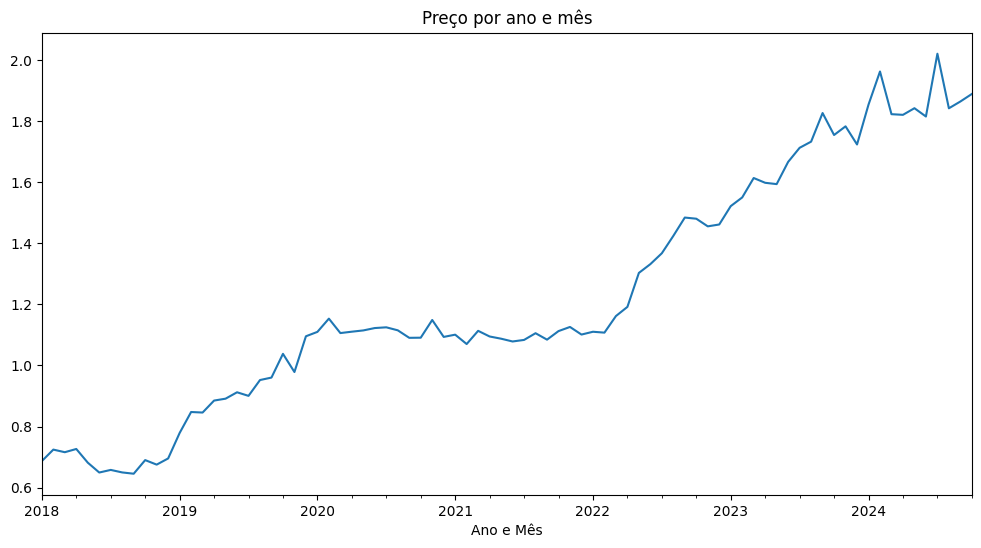

In [50]:
#Preço
Preco_por_mes = df.groupby('Ano e Mês')['Preço'].mean() #
Preco_por_mes.plot(kind= 'line',title='Preço por ano e mês',figsize=(12,6))

**Interpretação — Preço Médio por Ano e Mês**

O preço médio praticado pela BF LUBS apresenta **trajetória de alta ao longo do período**. Esse aumento é consistente com a hipótese levantada no gráfico de receita: a empresa vem reajustando seus preços, o que sustenta o faturamento, mas pode estar **acelerando a perda de clientes mais sensíveis ao preço**, especialmente os de maior volume, que têm maior poder de negociação ou encontram alternativas mais competitivas no mercado. A grande queda no volume de vendas em 2022 pode ser explicada pela grande alta dos preços no mesmo momento, no gráfico de Preço médio.

---
## 4. Análise por Produto

Compreendida a tendência geral, segmentamos os dados por **produto** para identificar quais itens do portfólio contribuem mais para o volume total e quais são os mais impactados pela queda.

<Axes: title={'center': 'Volume por Ano e Mês'}, xlabel='Ano e Mês'>

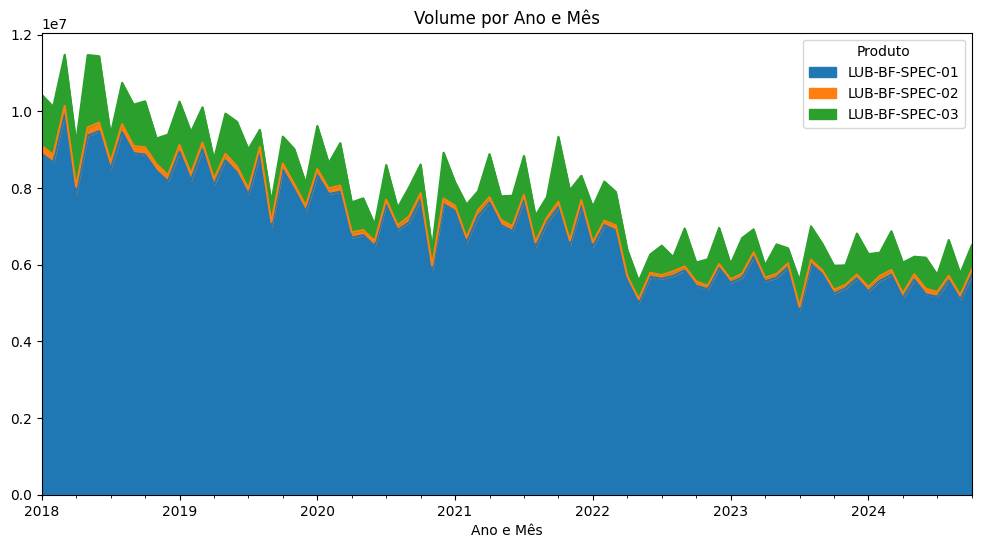

In [9]:
#Volume por Ano e Mês
produto_por_mes = df.groupby(['Ano e Mês', 'Produto'])['Volume'].sum().unstack()
produto_por_mes.plot(kind= 'area', title='Volume por Ano e Mês', figsize=(12,6))

**Interpretação — Volume por Produto ao Longo do Tempo**

O gráfico de área empilhada evidencia que o **Lubs1 domina o volume** em todos os períodos analisados e que sua redução é a principal responsável pela contração geral. Os demais produtos (Lubs2, Lubs3 etc.) apresentam volumes menores e relativamente mais estáveis, indicando que o problema está concentrado no principal produto da linha.

<Axes: title={'center': 'Volume por produto'}, xlabel='Produto'>

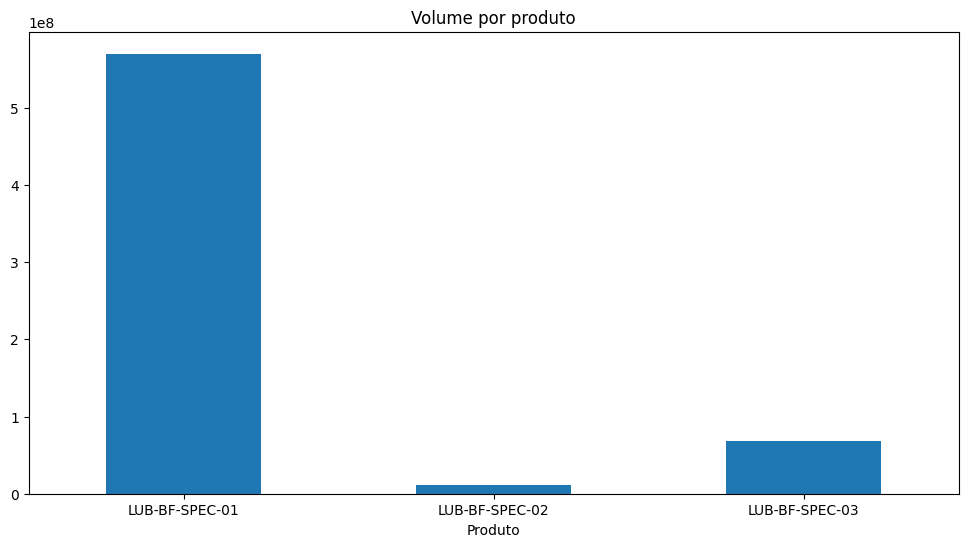

In [51]:
#Volume por produto
produto = df.groupby('Produto')['Volume'].sum()
produto.plot(kind= 'bar', title='Volume por produto', rot=0,figsize=(12,6))

**Interpretação — Volume Total por Produto**

O gráfico de barras confirma que o **Lubs1 responde pela maior parte do volume acumulado**, com folga significativa sobre os demais produtos. Essa concentração é um risco estratégico: qualquer deterioração no desempenho do Lubs1 tem impacto desproporcional sobre os resultados globais da empresa — exatamente o que os dados revelam estar acontecendo.

> **Insight:** A diversificação do portfólio ou ações específicas de retenção de clientes do Lubs1 devem ser prioridade estratégica.

---
## 5. Análise por Mercado

Com o produto-chave identificado, expandimos a análise para entender o comportamento por **segmento de mercado**, verificando quais setores industriais concentram maior volume e como evoluíram ao longo do tempo.

In [11]:
#UoM
#df['UoM'].unique()

<Axes: title={'center': 'Volume por ano e mês #mercado'}, xlabel='Ano e Mês'>

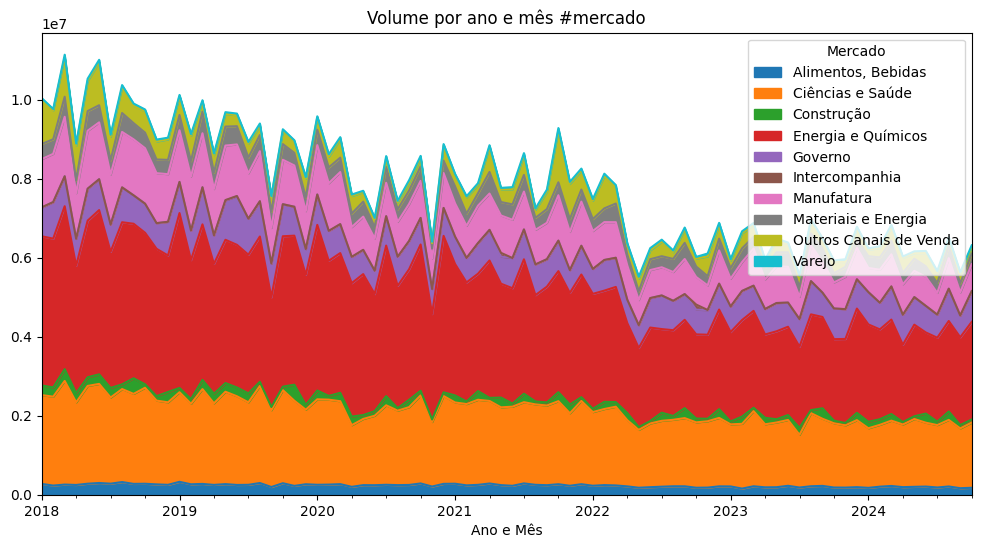

In [52]:
#Volume por Mercado
Mercado = df.groupby(['Ano e Mês','Mercado'])['Volume'].sum().unstack()
Mercado.plot(kind= 'area', title='Volume por ano e mês #mercado',figsize=(12,6))


**Interpretação — Volume por Mercado ao Longo do Tempo**

O gráfico de área por mercado mostra que a queda de volume é generalizada entre os segmentos, sem que um único setor isolado seja responsável pelo declínio. Por serem os maiores em volume, os mercados de **Energia e Químicos** e **Ciência e Saúde** contribuem mais para a queda absoluta.

<Axes: title={'center': 'Volume por mercado'}, xlabel='Mercado'>

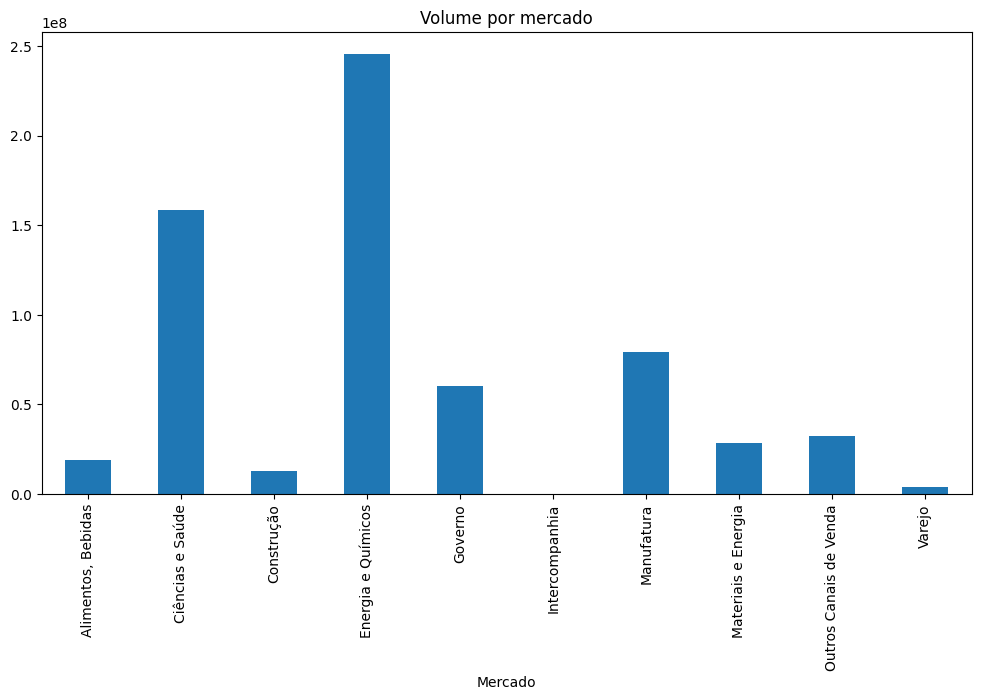

In [53]:
Mercado = df.groupby('Mercado')['Volume'].sum()
Mercado.plot(kind= 'bar', title='Volume por mercado',figsize=(12,6))

**Interpretação — Volume Total por Mercado**

Os três mercados que mais consomem produto da BF LUBS são **Energia e Químicos**, **Ciência e Saúde** e **Manufatura**. Juntos, representam a maior parte do volume total, tornando-se os segmentos prioritários tanto para ações de retenção quanto para investigações sobre por que a demanda vem caindo nessas verticais.

---
## 6. Análise Geográfica

Com o panorama de produto e mercado estabelecido, investigamos se a queda possui algum **padrão geográfico** — se determinadas regiões ou estados apresentam queda mais acentuada ou se o problema está distribuído de forma homogênea pelo território.

<Axes: title={'center': 'Região por Ano e Mês #Região'}, xlabel='Ano e Mês'>

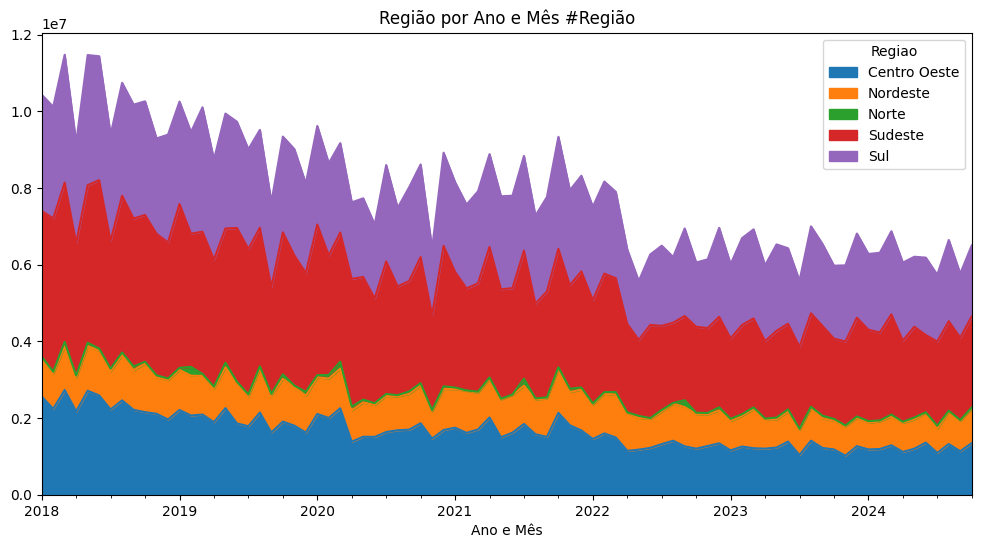

In [54]:
#Região por Ano e Mês
regiao_por_mes = df.groupby(['Ano e Mês', 'Regiao'])['Volume'].sum().unstack()
regiao_por_mes.plot(kind= 'area', title='Região por Ano e Mês #Região',figsize=(12,6))

**Interpretação — Volume por Região ao Longo do Tempo**

O gráfico de área por região mostra que **todas as regiões seguem a mesma tendência de queda**, sem que haja uma região cujo colapso se destaque significativamente sobre as demais. Isso reforça a hipótese de que o problema é sistêmico, e não localizado.

<Axes: title={'center': 'Volume por Região'}, xlabel='Regiao'>

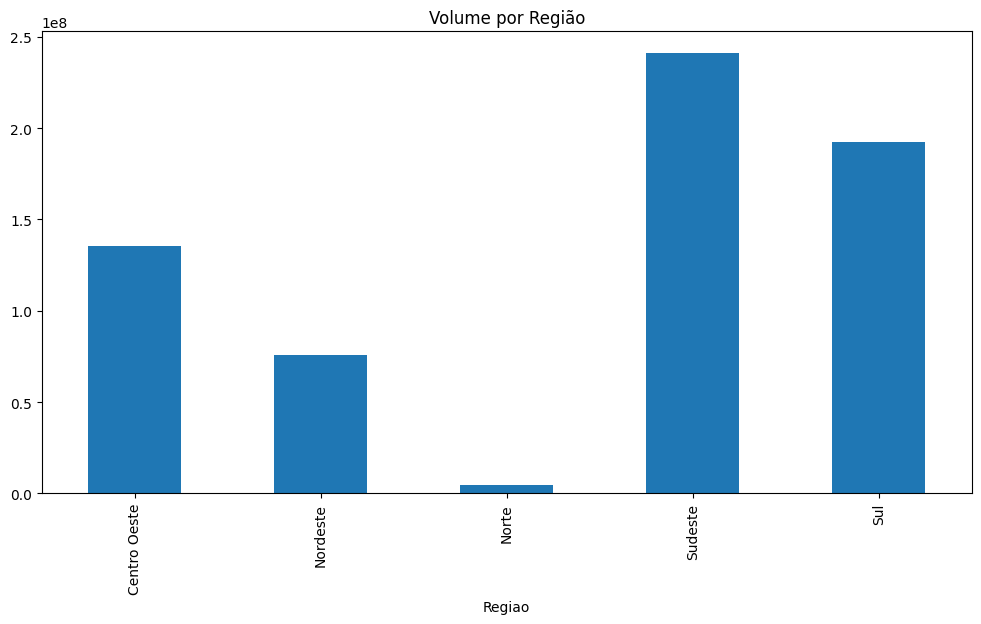

In [55]:
#Região
regiao = df.groupby('Regiao')['Volume'].sum()
regiao.plot(kind= 'bar', title='Volume por Região',figsize=(12,6))

**Interpretação — Volume Total por Região**

As regiões **Sul e Sudeste** concentram o maior volume acumulado, o que é esperado pela maior densidade industrial. A ausência de discrepância regional na queda indica que **não há fator logístico ou geográfico** como causa primária da deterioração.

---

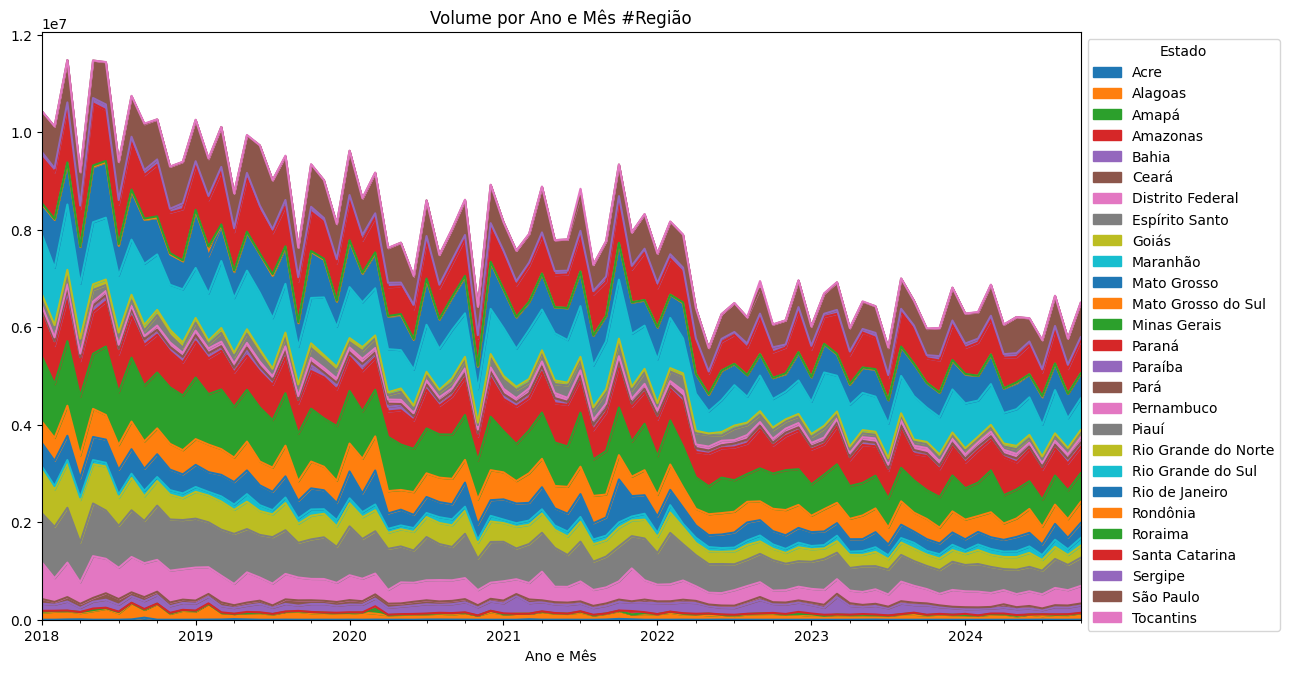

In [66]:
estado_por_mes = df.groupby(['Ano e Mês', 'Estado'])['Volume'].sum().unstack()
estado_por_mes.plot(kind='area', title='Volume por Ano e Mês #Região', figsize=(13,7))
plt.legend(loc='upper left', bbox_to_anchor=(1, 1), title='Estado')
plt.tight_layout()

**Interpretação — Volume por Estado ao Longo do Tempo**

Descendo até o nível de estado, a conclusão se mantém: **não há um estado específico com queda dramaticamente superior** aos demais. A queda é uniforme, o que descarta causas locais como mudanças regulatórias estaduais ou perda de um grande cliente regional isolado.

<Axes: title={'center': 'Volume por Estado'}, xlabel='Estado'>

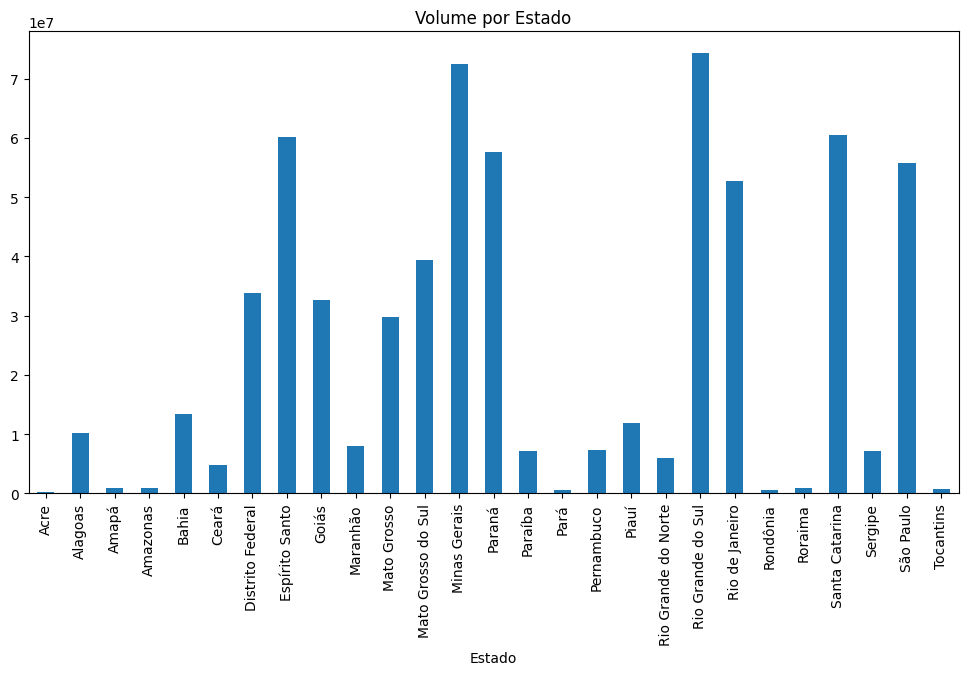

In [67]:
estado = df.groupby('Estado')['Volume'].sum()
estado.plot(kind= 'bar', title='Volume por Estado',figsize=(12,6))

**Interpretação — Volume Total por Estado**

Em volume acumulado, estados do **Sul e Sudeste** lideram, alinhados com a análise regional. A distribuição entre estados é relativamente equilibrada, sem outliers que indiquem problema pontual em um único estado.

> ✅ **Conclusão da análise geográfica:** A queda de volume é homogênea entre regiões e estados. O problema não é geográfico.

---
## 7. Segmentação de Clientes por Faixa de Volume

Uma vez descartadas causas geográficas, aprofundamos a análise no **perfil dos clientes**. Classificamos cada cliente por sua média mensal de volume comprado ao longo de todo o histórico, criando faixas que nos permitem entender quais perfis estão sendo perdidos e em que intensidade.

| Faixa | Volume Médio Mensal |
|---|---|
| Baixo | Até 300 L |
| Médio | 300 – 500 L |
| Alto | 500 – 900 L |
| Muito Alto | Acima de 900 L |

In [18]:
#Filial por Ano e Mês
#filial_por_mes = df.groupby(['Ano e Mês', 'Filial'])['Volume'].sum().unstack()
#filial_por_mes.plot(kind= 'area', title='Volume por Ano e Mês #Filial')

In [19]:
##filial = df.groupby('Filial')['Volume'].sum()
##filial.plot(kind= 'bar', title='Filial por mercado') 

<Axes: title={'center': 'Volume por Ano e Mês'}, xlabel='Ano e Mês'>

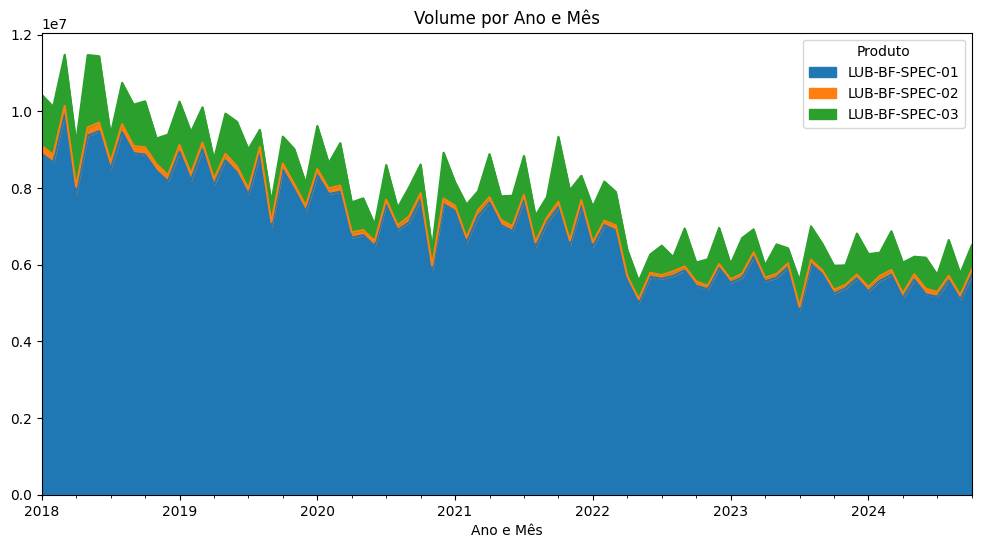

In [68]:
#Volume por Ano e Mês
produto_por_mes = df.groupby(['Ano e Mês', 'Produto'])['Volume'].sum().unstack()
produto_por_mes.plot(kind= 'area', title='Volume por Ano e Mês',figsize=(12,6))

<Axes: title={'center': 'Volume por mercado'}, xlabel='Mercado'>

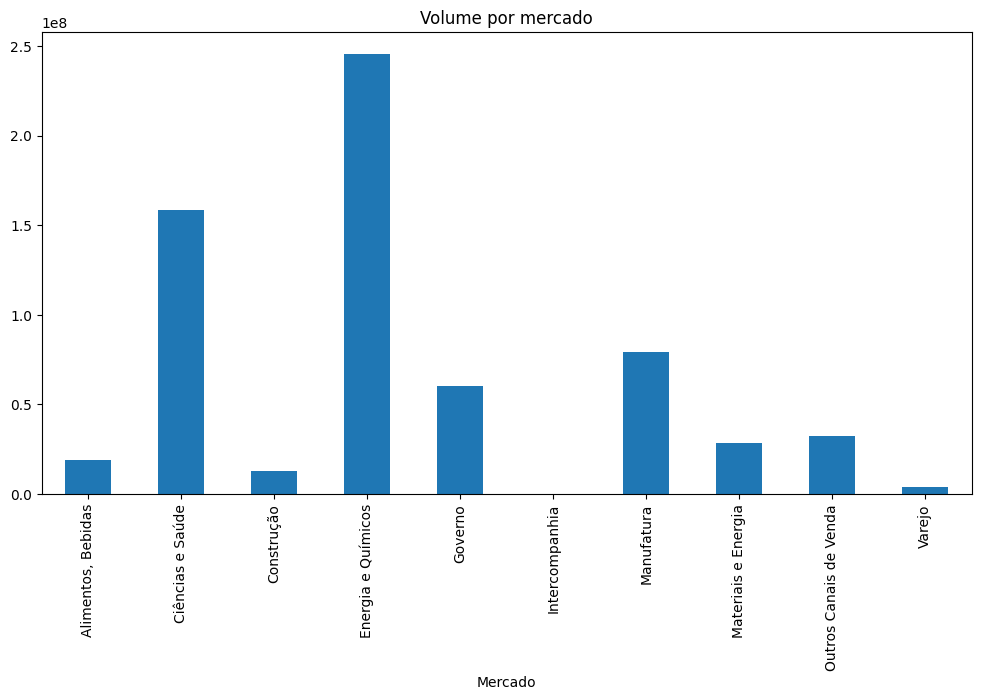

In [69]:
Mercado = df.groupby('Mercado')['Volume'].sum()
Mercado.plot(kind= 'bar', title='Volume por mercado',figsize=(12,6))

In [22]:
#Adicionando uma categoria pelo volume mendio mensal de clientes
volume_mensal_clientes = df.groupby(['Ano e Mês', 'ID Cliente'])['Volume'].sum().reset_index()
volume_mensal_clientes = volume_mensal_clientes.groupby('ID Cliente')['Volume'].mean().reset_index()

In [23]:
#Analisando a distribuição dos meus dados 
volume_mensal_clientes['Volume'].describe()

count    16,797.00
mean      1,432.92
std       8,308.42
min          10.00
25%         292.00
50%         474.50
75%         876.00
max     495,260.00
Name: Volume, dtype: float64

In [24]:
#Criando etiquetas/faixas de clientes por volume mensal

"""
 0 - 300    - Baixo
 300 - 500  - Médio
 500 - 900  - Alto
 900+ Muito - Alto
"""

bins = [0, 300, 500, 900, float('inf')]
labels = ['Baixo', 'Médio', 'Alto', "Muito alto" ]

In [25]:
#Adicionando a coluna da faixa para cada cliente
volume_mensal_clientes['Faixa de Volume'] = pd.cut(volume_mensal_clientes['Volume'], bins = bins, labels=labels )
volume_mensal_clientes = volume_mensal_clientes.drop(columns = ['Volume'])
volume_mensal_clientes.head()

,ID Cliente,Faixa de Volume
0,BF-CL1000000,Muito alto
1,BF-CL1000001,Muito alto
2,BF-CL1000002,Muito alto
3,BF-CL1000003,Muito alto
4,BF-CL1000004,Médio


In [ ]:
#Adicionando a faixa de volume do cliente no dataframe
df = pd.merge(
    df,
    volume_mensal_clientes,
    on = 'ID Cliente',
    how= 'left'
)
df.head()

,Ano e Mês,ID Cliente,Nome Cliente,Produto,UoM,Volume,Receita,Preço,Mercado,Regiao,Latitude_Regional,Longitude_Regional,Estado,Filial,Latitude_Filial,Longitude_Filial,Latitude_Cliente,Longitude_Cliente,Faixa de Volume
0,2023-10-01,BF-CL1000000,Cliente_1,LUB-BF-SPEC-01,LT,584,0,0.00,Outros Canais de Venda,Nordeste,-8.05,-34.88,Bahia,Ilhéus,-14.79,-39.05,-14.72,-39.01,Muito alto
1,2024-09-01,BF-CL1000001,Cliente_2,LUB-BF-SPEC-01,LT,3072,6895,2.25,Governo,Nordeste,-8.05,-34.88,Alagoas,Maceió,-9.65,-35.73,-9.66,-35.72,Muito alto
2,2022-12-01,BF-CL1000002,Cliente_3,LUB-BF-SPEC-01,LT,488,296,0.61,Governo,Nordeste,-8.05,-34.88,Paraíba,Campina Grande,-7.22,-35.88,-7.27,-35.52,Muito alto
3,2020-04-01,BF-CL1000003,Cliente_4,LUB-BF-SPEC-01,LT,1168,1430,1.22,Ciências e Saúde,Sudeste,-23.55,-46.63,Minas Gerais,Belo Horizonte,-19.92,-43.95,-20.21,-44.24,Muito alto
4,2021-12-01,BF-CL1000004,Cliente_5,LUB-BF-SPEC-01,LT,292,172,0.59,Ciências e Saúde,Centro Oeste,-15.78,-47.93,Mato Grosso,Várzea Grande,-15.65,-56.13,-15.99,-55.95,Médio


In [27]:
#faixa por volume do cliente
faixa_volume_cliente = df.groupby(['Ano e Mês', 'Faixa de Volume'])['Volume'].sum().unstack()
faixa_volume_cliente.head(10)

Faixa de Volume,Baixo,Médio,Alto,Muito alto
Ano e Mês,,,,
2018-01-01,75998,305113,721460,9333141
2018-02-01,72616,318915,653806,9076037
2018-03-01,84800,354770,782828,10257680
2018-04-01,74066,290180,643823,8178405
2018-05-01,78795,333969,745819,10312943
2018-06-01,77117,343252,753273,10266977
2018-07-01,69923,286595,676054,8358199
2018-08-01,73379,330626,735204,9607833
2018-09-01,67327,327610,688395,9094392


<Axes: title={'center': 'Volume por faixa de clientes'}, xlabel='Ano e Mês'>

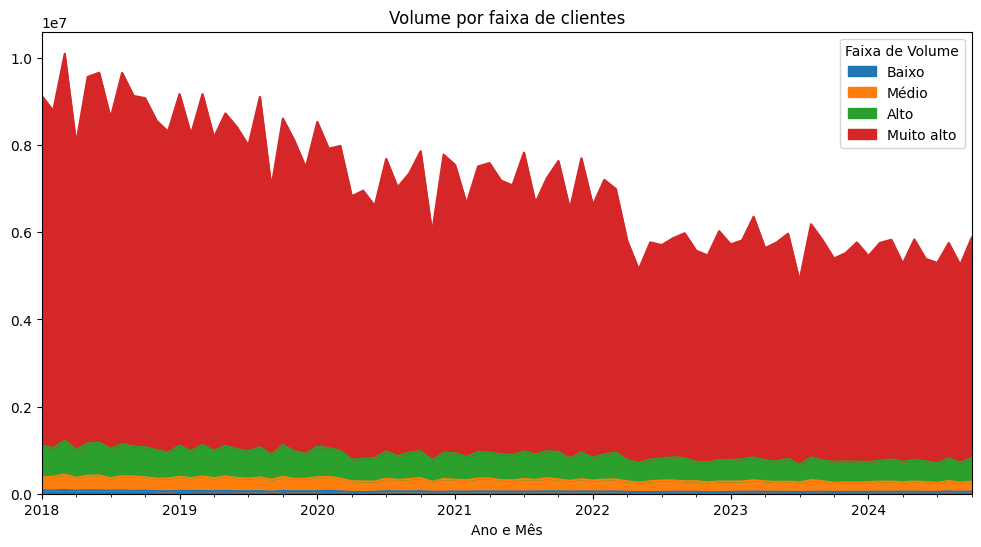

In [72]:
#Gráfico de Volume por faixa de clientes
faixa_volume_cliente.plot(kind='area', title='Volume por faixa de clientes',figsize=(12,6))

**Interpretação — Volume por Faixa de Clientes ao Longo do Tempo**

O gráfico revela de forma inequívoca onde está o maior problema: a faixa **"Muito Alto"** (clientes com compra média acima de 900 L/mês) sofreu a **maior contração de volume ao longo do período**. Enquanto as faixas inferiores apresentam queda mais suave ou relativa estabilidade, os grandes compradores reduziram drasticamente o volume adquirido, e são justamente eles que mais impactam o resultado total da empresa.

<Axes: title={'center': 'Clientes por Ano e Mês por faixa'}, xlabel='Ano e Mês'>

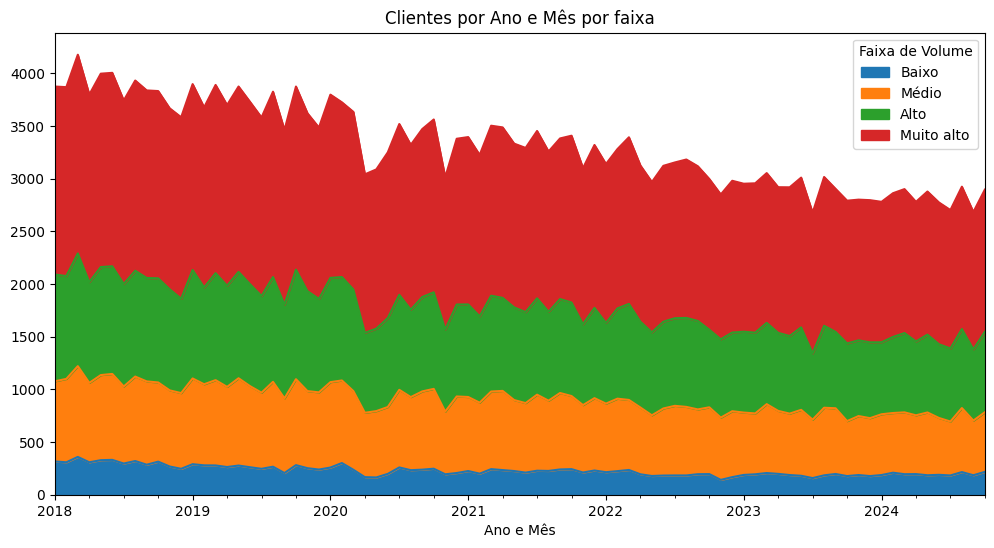

In [73]:
Clientes_por_mesfaixa = df.groupby(['Ano e Mês', 'Faixa de Volume'])['ID Cliente'].nunique().unstack()
Clientes_por_mesfaixa.plot(kind='area', title='Clientes por Ano e Mês por faixa',figsize=(12,6))

**Interpretação — Número de Clientes por Faixa ao Longo do Tempo**

Este gráfico complementa o anterior e agrava o diagnóstico: a faixa "Muito Alto" não apenas **comprou menos por cliente**, como também **perdeu clientes em número absoluto** de forma mais intensa que as demais faixas. Estamos diante de um cenário duplo: churn (saída) de grandes clientes combinado com redução do volume dos que permaneceram.

>**Alerta estratégico:** Perder clientes de alto volume é crítico. Cada cliente nessa faixa tem impacto equivalente a vários clientes de faixas menores. A prioridade de retenção deve estar aqui.

---
## 8. Identificação e Tratamento de Outliers

Antes de prosseguir para comparações entre períodos, é necessário garantir a **qualidade dos dados removendo registros atípicos (outliers)**. Valores extremamente altos podem distorcer médias e comparações, levando a conclusões equivocadas.

Utilizamos o método **IQR (Interquartile Range)** como ponto de partida, complementado por **conhecimento de domínio** sobre as operações logísticas da empresa.

## 5. Identificando Outliers

Usando o método do IQR (Interquartile Range) para a coluna `Volume`:

```python
# Calculando o IQR
Q1 = df[coluna].quantile(0.25)
Q3 = df[coluna].quantile(0.75)
IQR = Q3 - Q1

# Definir limites superior e inferior
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR


In [30]:
df['Volume'].describe()

count   601,836.00
mean      1,079.24
std       3,557.80
min           2.00
25%         292.00
50%         584.00
75%       1,168.00
max     240,042.00
Name: Volume, dtype: float64

In [31]:
Q1= df['Volume'].quantile(0.25)
Q3= df['Volume'].quantile(0.75)
IQR= Q3 - Q1


In [32]:
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

print(f'inferior {limite_inferior} e superior {limite_superior}')

inferior -1022.0 e superior 2482.0


In [33]:
#Identificando outliers inferiores
Outliers_inferiores = df[df['Volume']<= limite_inferior]
Outliers_inferiores.head()

,Ano e Mês,ID Cliente,Nome Cliente,Produto,UoM,Volume,Receita,Preço,Mercado,Regiao,Latitude_Regional,Longitude_Regional,Estado,Filial,Latitude_Filial,Longitude_Filial,Latitude_Cliente,Longitude_Cliente,Faixa de Volume


In [34]:
#Identificando outliers superiores
#Outliers_superiores = df[df['Volume']>= limite_superior]
Outliers_superiores = df[df['Volume']>= 20000]
Outliers_superiores.head()
Outliers_superiores.info()

<class 'pandas.DataFrame'>
Index: 1051 entries, 135 to 601261
Data columns (total 19 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Ano e Mês           1051 non-null   datetime64[us]
 1   ID Cliente          1051 non-null   str           
 2   Nome Cliente        1051 non-null   str           
 3   Produto             1051 non-null   str           
 4   UoM                 1051 non-null   str           
 5   Volume              1051 non-null   int64         
 6   Receita             1051 non-null   int64         
 7   Preço               1051 non-null   float64       
 8   Mercado             1027 non-null   str           
 9   Regiao              1051 non-null   str           
 10  Latitude_Regional   1051 non-null   float64       
 11  Longitude_Regional  1051 non-null   float64       
 12  Estado              1051 non-null   str           
 13  Filial              1051 non-null   str           
 14  Lati

**Resultado do Tratamento de Outliers**

Após calcular os limites pelo método IQR:

- **Limite inferior calculado:** −1.022 L — valor negativo e impossível fisicamente; **desconsiderado**.
- **Limite superior calculado:** 2.482 L — identificou ~50.000 entradas como outliers, o que é inviável. O critério estatístico puro não foi adequado para este caso.

Recorrendo ao **conhecimento de negócio**, foi identificado que o **veículo de maior capacidade da empresa transporta 20.000 L**. Qualquer pedido acima disso seria operacionalmente impossível em uma única entrega. Aplicando esse limite de domínio, foram identificados **1.051 registros** a serem removidos — um número razoável e justificável.



In [35]:
# Filtro para remoção de outliers

df_wo_outliers = df[df["Volume"] <= 20000]

<Axes: title={'center': 'Faixa de Volume por clientes'}, xlabel='Ano e Mês'>

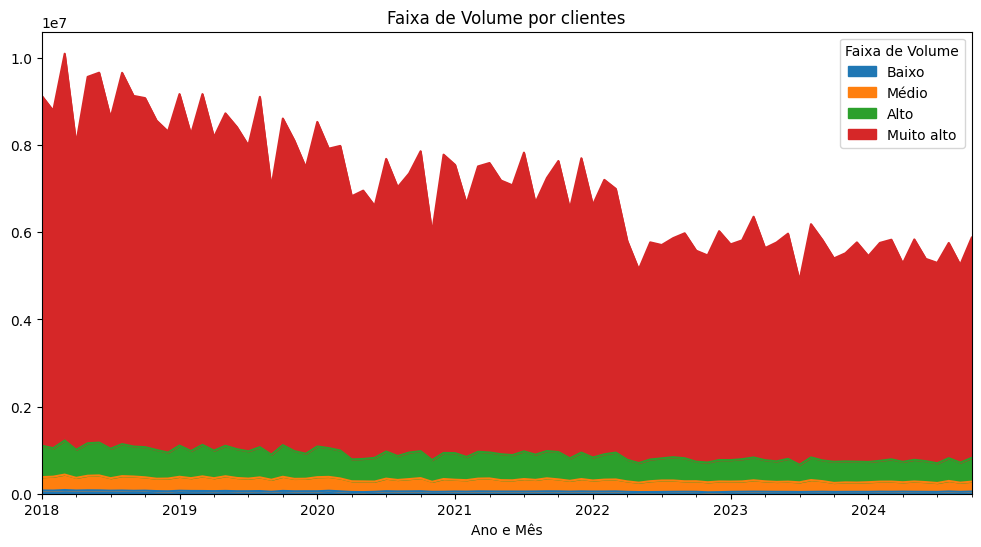

In [74]:
# Gráfico de volume por cliente sem outliers

faixa_volume_cliente = df_wo_outliers.groupby(['Ano e Mês', 'Faixa de Volume'])['Volume'].sum().unstack()
faixa_volume_cliente.plot(kind='area', title='Faixa de Volume por clientes',figsize=(12,6))

**Interpretação — Volume por Faixa (sem outliers)**

Com a remoção dos registros atípicos, o gráfico de faixas de volume mantém **exatamente a mesma tendência** observada anteriormente. Isso confirma que os outliers não estavam distorcendo a análise — a queda é real e estrutural, especialmente na faixa "Muito Alto". A remoção foi necessária para garantir a integridade das comparações quantitativas que seguem.

---
## 9. Comparação entre 2018 e 2024

Com a base de dados limpa, construímos uma análise comparativa focada nos **dois extremos do período**: 2018 (início) e 2024 (ano mais recente). O objetivo é quantificar exatamente **quanto volume médio mensal foi perdido** em cada combinação de Região, Mercado e Faixa de Cliente, permitindo priorizar ações de forma objetiva.

In [37]:
#df_wo_outliers.info()
#['Ano e Mês', 'Produto', 'Mercado', 'Regiao', 'Faixa de volume']

In [38]:
#Agrupando dados por 'Ano e Mês', 'Produto', 'Mercado', 'Regiao', 'Faixa de Volume'
volume_mensal = (
    df_wo_outliers.groupby(['Ano e Mês', 'Produto', 'Mercado', 'Regiao', 'Faixa de Volume'])['Volume']
    .sum()
    .reset_index()

)
volume_mensal['Ano'] = volume_mensal['Ano e Mês'].dt.year
volume_mensal = volume_mensal[volume_mensal['Ano'].isin([2018,2024])]
volume_mensal.head() #Dessa maneira temos uma tabela somente com as informações que precisamos.


,Ano e Mês,Produto,Mercado,Regiao,Faixa de Volume,Volume,Ano
0,2018-01-01,LUB-BF-SPEC-01,"Alimentos, Bebidas",Centro Oeste,Baixo,1168,2018
1,2018-01-01,LUB-BF-SPEC-01,"Alimentos, Bebidas",Centro Oeste,Médio,5548,2018
2,2018-01-01,LUB-BF-SPEC-01,"Alimentos, Bebidas",Centro Oeste,Alto,9344,2018
3,2018-01-01,LUB-BF-SPEC-01,"Alimentos, Bebidas",Centro Oeste,Muito alto,100740,2018
4,2018-01-01,LUB-BF-SPEC-01,"Alimentos, Bebidas",Nordeste,Baixo,1195,2018


In [39]:
#Verificando anos distintos após do filtro
volume_mensal['Ano'].unique()


array([2018, 2024], dtype=int32)

In [40]:
#Agrupando dados com a média mensal
volume_mensal_medio = (
    volume_mensal.groupby(['Ano', 'Produto', 'Mercado', 'Regiao', 'Faixa de Volume'])['Volume']
    .mean()
    .round(2) #Deixar apenas 2 casas decimais
    .rename('Volume Médio')
    .reset_index()

)
volume_mensal_medio.head()

,Ano,Produto,Mercado,Regiao,Faixa de Volume,Volume Médio
0,2018,LUB-BF-SPEC-01,"Alimentos, Bebidas",Centro Oeste,Baixo,"1,015.50"
1,2018,LUB-BF-SPEC-01,"Alimentos, Bebidas",Centro Oeste,Médio,"4,513.92"
2,2018,LUB-BF-SPEC-01,"Alimentos, Bebidas",Centro Oeste,Alto,"8,468.00"
3,2018,LUB-BF-SPEC-01,"Alimentos, Bebidas",Centro Oeste,Muito alto,"109,726.83"
4,2018,LUB-BF-SPEC-01,"Alimentos, Bebidas",Nordeste,Baixo,972.92


In [41]:
#Comparando os períodos
volume_sumarizado = pd.pivot_table(
    volume_mensal_medio,
    index = [ 'Regiao', 'Mercado', 'Faixa de Volume'],
    values = 'Volume Médio',
    columns = 'Ano',
    aggfunc = 'sum',
    margins = True,
    margins_name= 'Total geral'
).reset_index()



# Removendo valores maiores que 0 da tabela 
volume_sumarizado = volume_sumarizado[volume_sumarizado['Total geral'] > 0]
volume_sumarizado = volume_sumarizado[volume_sumarizado['Regiao']!= 'Total geral']

# Removendo total geral da tabela
volume_sumarizado = volume_sumarizado.drop(columns=['Total geral'])

# Gerando a diferença
volume_sumarizado['Dif.'] = volume_sumarizado[2024] - volume_sumarizado[2018]
volume_sumarizado['Dif %'] = volume_sumarizado['Dif.'] / volume_sumarizado[2018] * 100

volume_sumarizado.sort_values(by='Dif.', ascending=True).reset_index(drop=True).head()

Ano,Regiao,Mercado,Faixa de Volume,2018,2024,Dif.,Dif %
0,Sudeste,Energia e Químicos,Muito alto,"2,271,945.48","1,307,621.63","-964,323.85",-42.44
1,Sul,Ciências e Saúde,Muito alto,"769,482.08","515,672.60","-253,809.48",-32.98
2,Centro Oeste,Manufatura,Muito alto,"360,305.33","119,034.35","-241,270.98",-66.96
3,Centro Oeste,Energia e Químicos,Muito alto,"425,902.33","193,188.53","-232,713.80",-54.64
4,Sul,Energia e Químicos,Muito alto,"531,214.24","298,510.47","-232,703.77",-43.81


In [42]:
df_wo_outliers.head()

,Ano e Mês,ID Cliente,Nome Cliente,Produto,UoM,Volume,Receita,Preço,Mercado,Regiao,Latitude_Regional,Longitude_Regional,Estado,Filial,Latitude_Filial,Longitude_Filial,Latitude_Cliente,Longitude_Cliente,Faixa de Volume
0,2023-10-01,BF-CL1000000,Cliente_1,LUB-BF-SPEC-01,LT,584,0,0.00,Outros Canais de Venda,Nordeste,-8.05,-34.88,Bahia,Ilhéus,-14.79,-39.05,-14.72,-39.01,Muito alto
1,2024-09-01,BF-CL1000001,Cliente_2,LUB-BF-SPEC-01,LT,3072,6895,2.25,Governo,Nordeste,-8.05,-34.88,Alagoas,Maceió,-9.65,-35.73,-9.66,-35.72,Muito alto
2,2022-12-01,BF-CL1000002,Cliente_3,LUB-BF-SPEC-01,LT,488,296,0.61,Governo,Nordeste,-8.05,-34.88,Paraíba,Campina Grande,-7.22,-35.88,-7.27,-35.52,Muito alto
3,2020-04-01,BF-CL1000003,Cliente_4,LUB-BF-SPEC-01,LT,1168,1430,1.22,Ciências e Saúde,Sudeste,-23.55,-46.63,Minas Gerais,Belo Horizonte,-19.92,-43.95,-20.21,-44.24,Muito alto
4,2021-12-01,BF-CL1000004,Cliente_5,LUB-BF-SPEC-01,LT,292,172,0.59,Ciências e Saúde,Centro Oeste,-15.78,-47.93,Mato Grosso,Várzea Grande,-15.65,-56.13,-15.99,-55.95,Médio


---
## 10. Visualizando os Impactos entre 2018 e 2024

Com a tabela comparativa construída, geramos visualizações da **diferença de volume médio mensal** entre 2018 e 2024, segmentadas por região e mercado. Valores negativos indicam queda — quanto maior o valor absoluto, maior a perda acumulada naquele segmento.

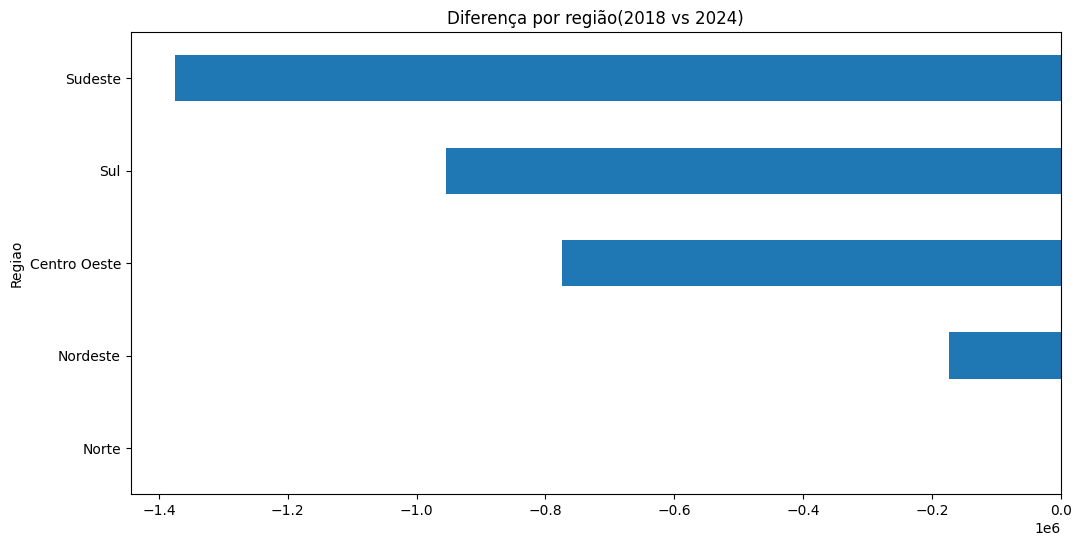

In [77]:
# Região

regiao_dif = volume_sumarizado.groupby('Regiao')['Dif.'].sum().sort_values(ascending=False)
regiao_dif.plot(kind='barh', figsize=(12,6))
plt.title('Diferença por região(2018 vs 2024)')
plt.show()

**Interpretação — Diferença de Volume por Região (2018 vs 2024)**

O gráfico evidencia que basicamente **todas as regiões apresentam variação negativa**, confirmando a natureza sistêmica da queda. As regiões de maior volume histórico (Sul e Sudeste) naturalmente registram as maiores perdas absolutas, mas a proporcionalidade sugere que nenhuma região está imune ao problema.

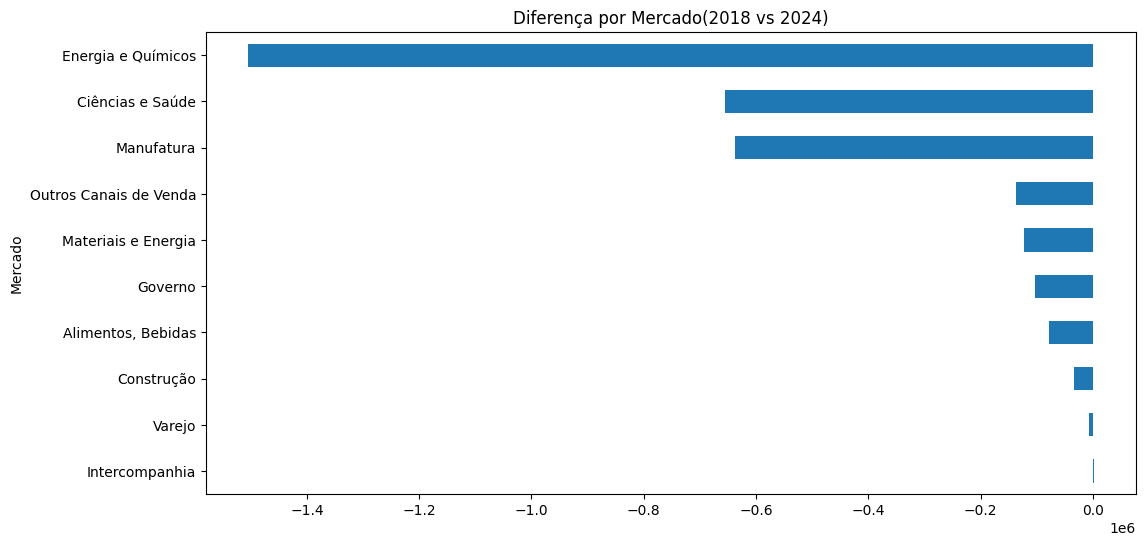

In [79]:
#Mercado
mercado_dif = volume_sumarizado.groupby('Mercado')['Dif.'].sum().sort_values(ascending=False)
mercado_dif.plot(kind='barh', figsize=(12,6))
plt.title('Diferença por Mercado(2018 vs 2024)')
plt.show()



**Interpretação — Diferença de Volume por Mercado (2018 vs 2024)**

A queda de volume não é uniforme entre os mercados — ela é **fortemente concentrada em três segmentos**:
**Energia e Químicos**, **Ciências e Saúde** e **Manufatura** respondem pela esmagadora maioria
da perda acumulada. Esse padrão indica que o problema da BF LUBS está **concentrado nos seus mercados mais relevantes**,
a empresa está perdendo volume justamente onde mais importa. Ações de retenção e recuperação devem ser direcionadas prioritariamente a esses três segmentos.


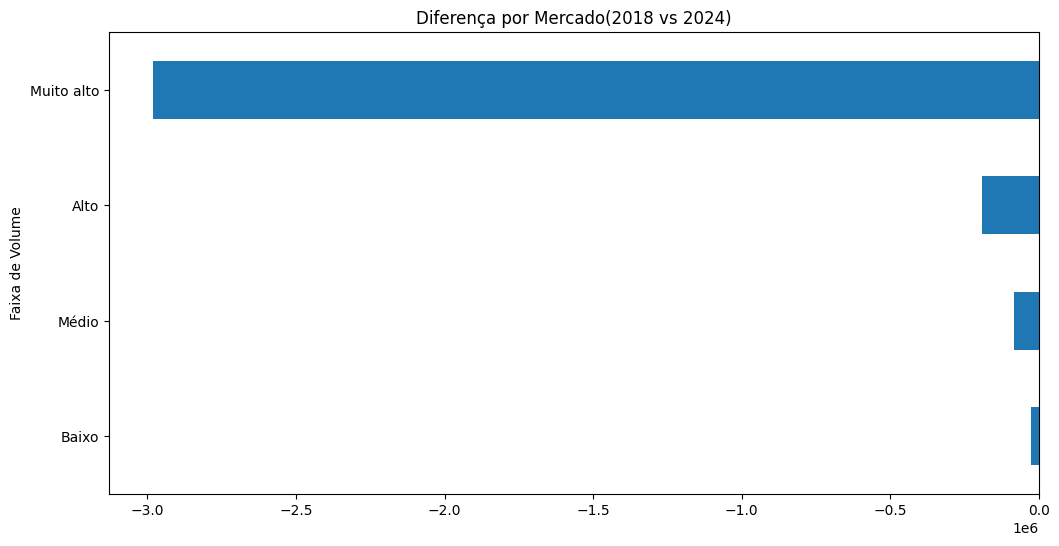

In [78]:
#Faixa de Volume
mercado_dif = volume_sumarizado.groupby('Faixa de Volume')['Dif.'].sum().sort_values(ascending=False)
mercado_dif.plot(kind='barh', figsize=(12,6))
plt.title('Diferença por Mercado(2018 vs 2024)')
plt.show()

**Interpretação — Diferença de Volume por Faixa de Cliente (2018 vs 2024)**

A faixa **"Muito Alto"** concentra praticamente toda a queda acumulada de volume, com perda
absolutamente desproporcional em relação às demais faixas. As faixas "Alto", "Médio" e "Baixo"
apresentam variações quase irrelevantes em comparação — confirmando que o problema central
da BF LUBS é a **perda de seus maiores clientes**, e não uma erosão distribuída pela base.

## 11. Análise de Pareto — Identificando os Maiores Offenders

A etapa final aplica o **Princípio de Pareto (80/20)** para identificar **quais combinações de Região + Mercado + Faixa de Cliente** concentram a maior parte da queda acumulada de volume. Essa visão permite à liderança da BF LUBS agir de forma cirúrgica, priorizando os segmentos com maior potencial de recuperação de volume.

In [45]:
#Preparando para análise de Pareto
pareto_df= volume_sumarizado
pareto_df['Regiao Mercado e Volume'] = pareto_df['Regiao'] + ' | ' + pareto_df['Mercado']+ ' | ' + pareto_df['Faixa de Volume']
pareto_df = pareto_df.sort_values(by='Dif.')#Ordenando valores
pareto_df = pareto_df[pareto_df['Dif.']<0] #Removendo Positivos
pareto_df['Dif.'] = pareto_df['Dif.'].abs()#Transformando negativo em absoluto
pareto_df= pareto_df[['Regiao', 'Mercado', 'Faixa de Volume', 'Regiao Mercado e Volume', 'Dif.']] #selecionando coluna

pareto_df['Dif % Acumulado'] = pareto_df['Dif.'].cumsum() / pareto_df['Dif.'].sum() * 100 #adicionando % acumulado

pareto_df.head()

Ano,Regiao,Mercado,Faixa de Volume,Regiao Mercado e Volume,Dif.,Dif % Acumulado
98,Sudeste,Energia e Químicos,Muito alto,Sudeste | Energia e Químicos | Muito alto,"964,323.85",28.95
127,Sul,Ciências e Saúde,Muito alto,Sul | Ciências e Saúde | Muito alto,"253,809.48",36.57
25,Centro Oeste,Manufatura,Muito alto,Centro Oeste | Manufatura | Muito alto,"241,270.98",43.82
15,Centro Oeste,Energia e Químicos,Muito alto,Centro Oeste | Energia e Químicos | Muito alto,"232,713.80",50.81
135,Sul,Energia e Químicos,Muito alto,Sul | Energia e Químicos | Muito alto,"232,703.77",57.79


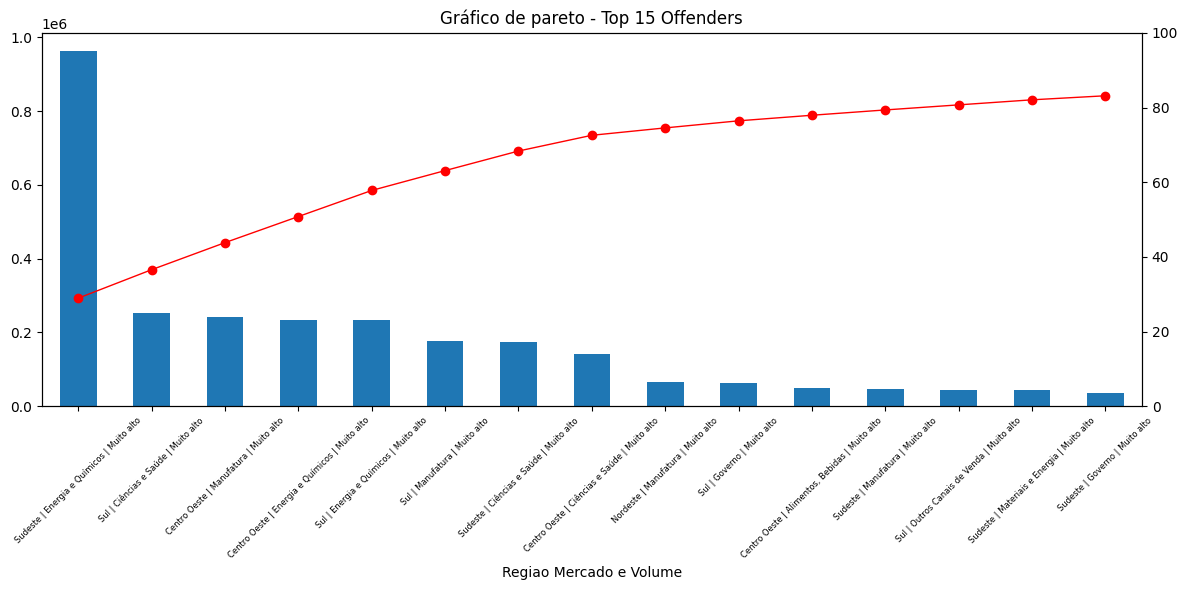

In [90]:
#Selecionando top 15 dif.

pareto_top15 = pareto_df.nlargest(15, 'Dif.')

#Gráfico de Pareto

#Eixo principal
ax = pareto_top15.plot(kind='bar', x= 'Regiao Mercado e Volume', y='Dif.', legend=False, figsize=(12,6))

#Eixo secundário para visualização da porcentagem acumulada
ax2 = ax.twinx()
ax2.plot(
    pareto_top15['Regiao Mercado e Volume'],
    pareto_top15['Dif % Acumulado'],
    color = 'red', marker= 'o', linestyle = '-', linewidth=1, 
)

#Formatando o gráfico
ax2.set_ylim(0,100)#Limite do eixo secundário
ax.tick_params(axis='x', rotation=45, labelsize=6)#ajustando rótulos
ax.set_title('Gráfico de pareto - Top 15 Offenders') #Título


plt.tight_layout()
plt.show()

**Interpretação — Gráfico de Pareto (Top 15 Segmentos)**

O gráfico de Pareto combina **barras** (queda absoluta de volume por segmento) com uma **linha de porcentagem acumulada** (eixo direito). Os primeiros segmentos à esquerda são os maiores responsáveis pela queda total.

A linha cruza rapidamente o limiar de 80%, confirmando que **um número pequeno de combinações de Região + Mercado + Faixa de Volume** concentra a maior parte da perda. Esses são os segmentos que exigem atenção imediata; sejam alvos de programas de fidelização, renegociação de condições comerciais ou investigação de causa raiz junto aos próprios clientes.



### Principais Achados

A análise exploratória dos dados de vendas da BF LUBS entre 2018 e 2024 revelou um cenário de **deterioração estrutural e consistente** em toda a operação comercial da empresa:

- O **volume total vendido caiu de forma contínua** ao longo de todo o período, com quedas mais abruptas entre 2018–2020 e novamente em 2022.
- A **receita se manteve relativamente estável**, sustentada por um aumento progressivo do preço médio — o que mascara a gravidade da perda de base de clientes.
- O **número de clientes ativos caiu consistentemente**, indicando que o problema não é apenas de volume por cliente, mas de churn real.
- O produto **Lubs1 é o epicentro da queda**, respondendo pela maior parte do volume perdido dado seu peso dominante no portfólio.
- Os mercados de **Energia e Químicos**, **Ciências e Saúde** e **Manufatura** concentram as maiores perdas absolutas — e são justamente os mais estratégicos para a empresa.
- A queda **não possui padrão geográfico**: todas as regiões e estados declinaram de forma proporcional, descartando causas locais ou logísticas.
- A faixa de clientes **"Muito Alto"** (acima de 900 L/mês) é responsável pela esmagadora maioria da queda acumulada — tanto em volume quanto em número de clientes perdidos.
- O **Pareto confirmou** que um pequeno grupo de combinações Região + Mercado + Faixa concentra a maior parte da perda, permitindo priorização cirúrgica de ações.

---

### Respostas às Perguntas de Negócio

| Pergunta | Resposta |
|---|---|
| O volume de vendas está caindo? |  Sim — queda contínua de 2018 a 2024, sem sinais de reversão |
| A queda impacta a receita? |  Ainda não diretamente — o aumento de preço compensa, mas é insustentável |
| Quais produtos são os mais afetados? | O **Lubs1** é o principal responsável pela queda |
| A queda está concentrada em algum mercado? | Sim — **Energia e Químicos**, **Ciências e Saúde** e **Manufatura** |
| Há padrão geográfico na queda? |  Não — a queda é homogênea entre regiões e estados |
| Quais perfis de clientes estão sendo mais perdidos? | Clientes da faixa **"Muito Alto"**, de forma massivamente desproporcional |
| A empresa perde clientes ou volume por cliente? | **Ambos** — churn e redução de consumo ocorrem simultaneamente na faixa crítica |
| Existem outliers distorcendo a análise? | Sim — 1.051 registros acima da capacidade logística máxima foram removidos, porém, os gráficos não foram afetados significativamente|
| Quais segmentos concentram a maior parte da queda? | Os primeiros segmentos do Pareto (Sudeste + Energia e Químicos + Muito Alto, entre outros) explicam ~80% da perda |

---

### Sugestão de Ações Futuras

**1. Retenção dos clientes "Muito Alto"**
Investigar individualmente os clientes dessa faixa que reduziram volume ou saíram. Entrevistas qualitativas podem revelar se o problema é preço, qualidade, concorrência ou atendimento.

**2. Revisão da estratégia de precificação**
O aumento contínuo de preço pode estar acelerando a saída dos maiores clientes, que têm mais poder de negociação e mais alternativas no mercado. Uma análise de elasticidade-preço por faixa de cliente é recomendada.

**3. Foco comercial nos mercados críticos**
Concentrar esforços de retenção e prospecção nos segmentos de **Energia e Químicos**, **Ciências e Saúde** e **Manufatura**, onde a perda absoluta é maior e o potencial de recuperação é mais significativo.

**4. Plano de ação orientado pelo Pareto**
Utilizar os Top 15 segmentos identificados na análise de Pareto como lista de prioridades para o time comercial, com metas específicas de recuperação de volume por segmento.

**5. Monitoramento contínuo com dashboards**
Implementar acompanhamento mensal das métricas-chave (volume, clientes ativos, churn por faixa) para detectar sinais de deterioração com antecedência e agir de forma proativa.

## Conclusão
A BF LUBS enfrenta um problema estrutural de perda de clientes de alto valor. A queda de volume não é pontual ou sazonal — é uma tendência de longo prazo que impacta de forma transversal regiões, estados e mercados. A prioridade estratégica deve ser a **retenção e recuperação dos clientes de faixa "Muito Alto"**, com foco especial nos segmentos identificados na análise de Pareto.
